import dataset

In [30]:
import os
os.environ['KAGGLE_USERNAME'] = 'mohammedanas2005'
os.environ['KAGGLE_KEY'] = 'KGAT_a18b4e39b7042a73dd45022897044339'

In [31]:
!kaggle datasets download -d "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
!unzip -qq gtsrb-german-traffic-sign.zip



Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
gtsrb-german-traffic-sign.zip: Skipping, found more recently modified local copy (use --force to force download)
replace Meta.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

import libraries

In [32]:
import tensorflow as tf
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras

Training the dataset

In [33]:
train_data_dir = "Train"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(

    train_data_dir,

    image_size=(30,30),

    batch_size=32,

    validation_split=0.2,

    subset="training",

    seed=42

)



Found 39209 files belonging to 43 classes.
Using 31368 files for training.


Validation dataset

In [34]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(

    train_data_dir,

    image_size=(30,30),

    batch_size=32,

    validation_split=0.2,

    subset="validation",

    seed=42)


Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


display dataset information

In [35]:
print(train_dataset.class_names)

print("Total classes:",len(train_dataset.class_names))

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']
Total classes: 43


Visualize sample traffic sign images

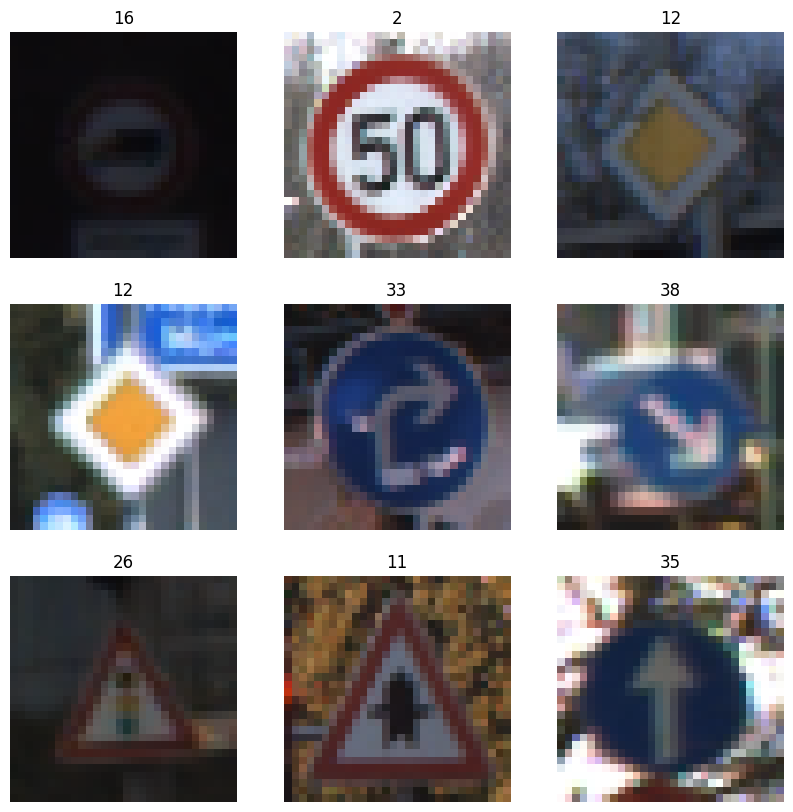

In [36]:
plt.figure(figsize=(10,10))

class_name=train_dataset.class_names

for images,labels in train_dataset.take(1):

    for i in range(9):

        ax=plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_name[labels[i]])

        plt.axis("off")

plt.show()

Normalize image pixel values

In [37]:
normalization_layer=tf.keras.layers.Rescaling(1./255)

train_dataset=train_dataset.map(lambda x,y:(normalization_layer(x),y))

validation_dataset=validation_dataset.map(lambda x,y:(normalization_layer(x),y))

In [38]:
for images,labels in train_dataset.take(1):
  print("Minimum:",tf.reduce_min(images).numpy())
  print("Maximum:",tf.reduce_max(images).numpy())

Minimum: 0.022156855
Maximum: 1.0


Data  Augumentation

In [39]:
data_augumentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

build CNN model

In [40]:
model = keras.Sequential([

    data_augumentation,

    keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(30,30,3)),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(128,(3,3),activation="relu"),
    keras.layers.MaxPooling2D(),

    keras.layers.Flatten(),

    keras.layers.Dense(256,activation="relu"),

    keras.layers.Dropout(0.5),

    keras.layers.Dense(43,activation="softmax")

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


display model summary

In [41]:
model.build((None,30,30,3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 30, 30, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,627 (920.42 KB)

 Trainable params: 235,627 (920.42 KB)

 Non-trainable params: 0 (0.00 B)

compile the model

In [42]:
 model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Train the cnn model

In [43]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - accuracy: 0.3499 - loss: 2.2185 - val_accuracy: 0.6245 - val_loss: 1.1351
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 70s 71ms/step - accuracy: 0.6257 - loss: 1.1115 - val_accuracy: 0.7928 - val_loss: 0.5954
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 69s 70ms/step - accuracy: 0.7492 - loss: 0.7384 - val_accuracy: 0.8688 - val_loss: 0.4188
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 63s 64ms/step - accuracy: 0.8124 - loss: 0.5527 - val_accuracy: 0.9013 - val_loss: 0.2980
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - accuracy: 0.8515 - loss: 0.4462 - val_accuracy: 0.9311 - val_loss: 0.2207
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.8751 - loss: 0.3760 - val_accuracy: 0.9379 - val_loss: 0.2003
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - accuracy: 0.8891 - loss: 0.3333 - val_accuracy: 0.9514 - val_loss: 0.1516
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.9008 - loss: 0.2956 - 

plot training and validation accuracy

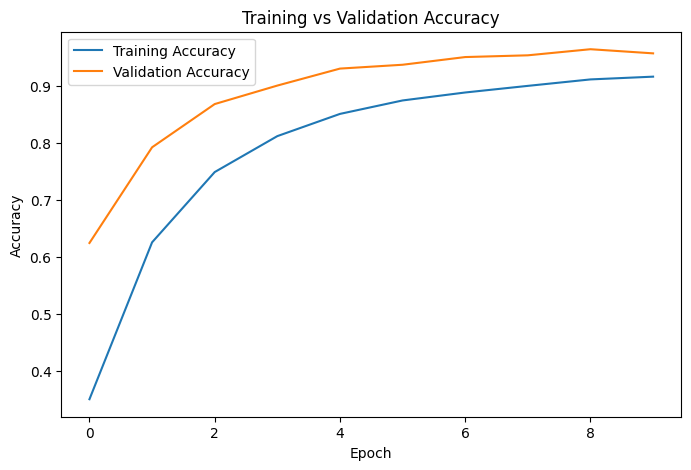

In [44]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plot training and validation loss

```



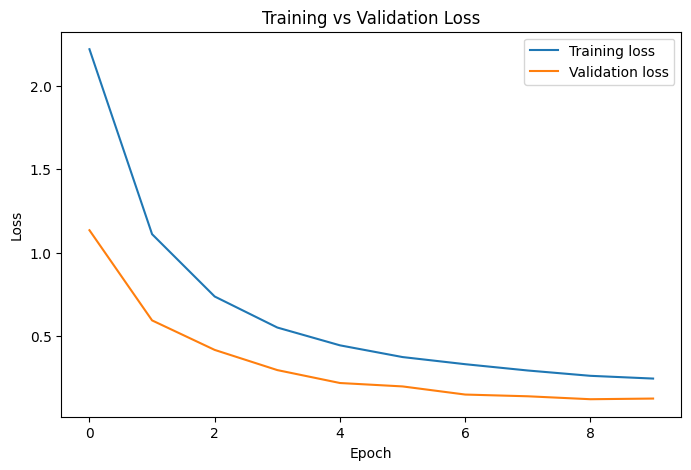

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

evaluate model performance

In [46]:
loss, accuracy = model.evaluate(validation_dataset)
print("Validation Loss:",loss)
print("Validation Accuracy:",accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9579 - loss: 0.1277
Validation Loss: 0.12766632437705994
Validation Accuracy: 0.9579135179519653


save the trained model

In [86]:
model.save("traffic_sign_model.keras")

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

load test image

In [49]:
test = pd.read_csv("Test.csv")

preprocess test *image*

In [159]:
no_entry = test[test["ClassId"] == 36]
img_path = no_entry.iloc[0]["Path"]

predict the traffic sign

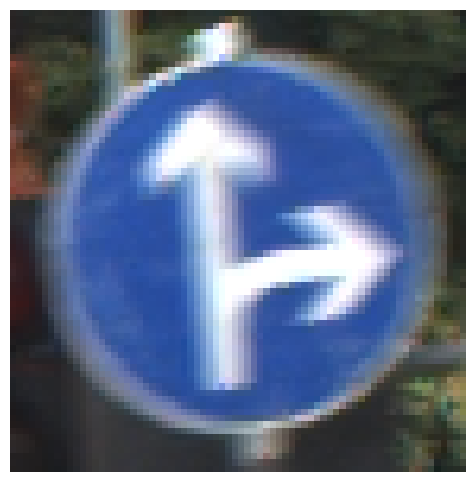

In [160]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [161]:
img_input = cv2.resize(img,(30,30))
img_input = img_input/255.0
img_input = np.expand_dims(img_input,axis=0)

In [162]:
prediction=model.predict(img_input)
predicted_class=np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [163]:
traffic_signs = {
    0: "Speed limit (20km/h)",
    1: "Speed limit (30km/h)",
    2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)",
    4: "Speed limit (70km/h)",
    5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)",
    7: "Speed limit (100km/h)",
    8: "Speed limit (120km/h)",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

display predicted image with label

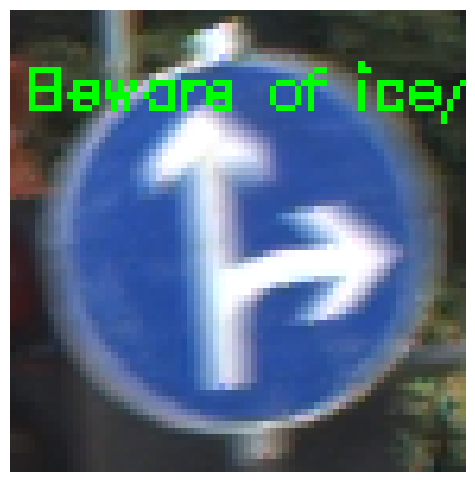

In [164]:
label = traffic_signs[predicted_class]

img_display = img.copy()

cv2.putText(
    img_display,
    label,
    (2, 15),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.3,
    (0, 255, 0),
    1
)

plt.figure(figsize=(6,6))
plt.imshow(img_display)
plt.axis("off")
plt.show()

display safety alert message

In [165]:
predicted_class_id = int(class_name[predicted_class])

print("Actual Class:", no_entry.iloc[0]["ClassId"])
print("Predicted Class:", predicted_class_id)
print("Traffic Sign:", traffic_signs[predicted_class_id])

Actual Class: 36
Predicted Class: 36
Traffic Sign: Go straight or right
